In [ ]:
# ============================================
# CELL 1: Mount Google Drive and Setup
# ============================================
from google.colab import drive
drive.mount('/content/drive')

# Create project folder
!mkdir -p /content/drive/MyDrive/dropout-project/models
!mkdir -p /content/drive/MyDrive/dropout-project/results

print("✅ Google Drive mounted and folders created")

Mounted at /content/drive
✅ Google Drive mounted and folders created


In [ ]:
# ============================================
# CELL 2: Install Required Libraries
# ============================================
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn joblib xgboost shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score)
from sklearn.preprocessing import label_binarize
import joblib
import warnings
import os
import zipfile
from google.colab import files

warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


In [ ]:
# ============================================
# CELL 3: Upload Preprocessed Data (from Gangadhara)
# ============================================
from google.colab import files

print("📤 Please upload the ZIP file from Gangadhara")
print("Click 'Choose Files' and select: student_dropout_complete_data.zip")

uploaded = files.upload()

# Extract the ZIP file
!unzip -o student_dropout_complete_data.zip

print("\n✅ Files extracted successfully!")
!ls -la *.csv *.npy *.pkl

📤 Please upload the ZIP file from Gangadhara
Click 'Choose Files' and select: student_dropout_complete_data.zip


Saving student_dropout_complete_data.zip to student_dropout_complete_data.zip
Archive:  student_dropout_complete_data.zip
 extracting: student_dropout_preprocessed_full.csv  
 extracting: student_dropout_encoded.csv  
 extracting: student_dropout_train.csv  
 extracting: student_dropout_test.csv  
 extracting: student_dropout_train_selected.csv  
 extracting: student_dropout_test_selected.csv  
 extracting: feature_importance.csv  
 extracting: X_train_scaled.npy      
 extracting: X_test_scaled.npy       
 extracting: y_train.npy             
 extracting: y_test.npy              
 extracting: X_train_selected.npy    
 extracting: X_test_selected.npy     
 extracting: label_encoder.pkl       
 extracting: scaler.pkl              
 extracting: feature_names.pkl       
 extracting: selected_features.pkl   
 extracting: feature_selector.pkl    
 extracting: target_distribution.png  
 extracting: feature_importance.png  

✅ Files extracted successfully!
-rw-r--r-- 1 root root     2112 Feb 

In [ ]:
# ============================================
# CELL 4: Load the Training Data
# ============================================
print("="*60)
print("📊 LOADING PREPROCESSED DATA")
print("="*60)

# OPTION 1: Use selected features (RECOMMENDED - 24 features)
df_train = pd.read_csv('student_dropout_train_selected.csv')
df_test = pd.read_csv('student_dropout_test_selected.csv')

# OPTION 2: Use all features (48 features) - uncomment if needed
# df_train = pd.read_csv('student_dropout_train.csv')
# df_test = pd.read_csv('student_dropout_test.csv')

print(f"\n✅ Training set: {df_train.shape}")
print(f"✅ Test set: {df_test.shape}")

# Separate features and target
X_train = df_train.drop('Target', axis=1)
y_train = df_train['Target']
X_test = df_test.drop('Target', axis=1)
y_test = df_test['Target']

# Load feature names
feature_names = X_train.columns.tolist()
print(f"\n📋 Feature names ({len(feature_names)} features):")
print(feature_names[:10])  # Show first 10

# Load label encoder to understand classes
if os.path.exists('label_encoder.pkl'):
    le = joblib.load('label_encoder.pkl')
    class_names = le.classes_
    print(f"\n🎯 Target classes: {class_names}")
    print(f"   Mapping: 0={class_names[0]}, 1={class_names[1]}, 2={class_names[2]}")
else:
    class_names = ['Dropout', 'Enrolled', 'Graduate']
    print(f"\n🎯 Target classes (assumed): {class_names}")

📊 LOADING PREPROCESSED DATA

✅ Training set: (5301, 25)
✅ Test set: (885, 25)

📋 Feature names (24 features):
['Course', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Tuition fees up to date', 'Age at enrollment', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)']

🎯 Target classes: ['Dropout' 'Enrolled' 'Graduate']
   Mapping: 0=Dropout, 1=Enrolled, 2=Graduate



📊 TARGET DISTRIBUTION

Training set distribution:
   Class 0: 1767 samples (33.3%)
   Class 1: 1767 samples (33.3%)
   Class 2: 1767 samples (33.3%)

Test set distribution:
   Class 0: 284 samples (32.1%)
   Class 1: 159 samples (18.0%)
   Class 2: 442 samples (49.9%)


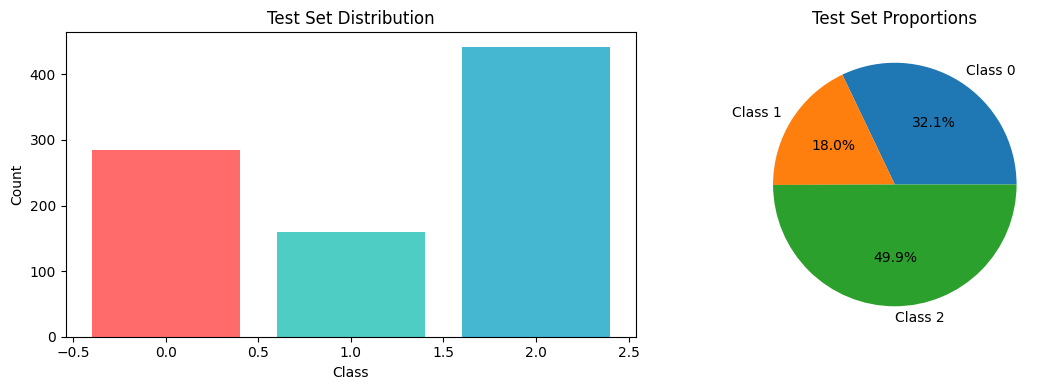

In [ ]:
# ============================================
# CELL 5: Explore Target Distribution
# ============================================
print("\n" + "="*60)
print("📊 TARGET DISTRIBUTION")
print("="*60)

unique, counts = np.unique(y_train, return_counts=True)
print(f"\nTraining set distribution:")
for u, c in zip(unique, counts):
    print(f"   Class {int(u)}: {c} samples ({c/len(y_train)*100:.1f}%)")

unique, counts = np.unique(y_test, return_counts=True)
print(f"\nTest set distribution:")
for u, c in zip(unique, counts):
    print(f"   Class {int(u)}: {c} samples ({c/len(y_test)*100:.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(unique, counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_title('Test Set Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

axes[1].pie(counts, labels=[f'Class {int(u)}' for u in unique], autopct='%1.1f%%')
axes[1].set_title('Test Set Proportions')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300)
plt.show()

In [ ]:
# ============================================
# CELL 6: Quick Data Overview
# ============================================
print("\n" + "="*60)
print("📋 DATA OVERVIEW")
print("="*60)

print(f"\n📊 Training data shape: {X_train.shape}")
print(f"📊 Test data shape: {X_test.shape}")
print(f"\n📈 Feature statistics:")
print(pd.DataFrame(X_train).describe())

print(f"\n🔍 Check for missing values:")
print(f"Training missing: {np.isnan(X_train).sum().sum()}")
print(f"Test missing: {np.isnan(X_test).sum().sum()}")

print(f"\n✅ Data is ready for model training!")


📋 DATA OVERVIEW

📊 Training data shape: (5301, 24)
📊 Test data shape: (885, 24)

📈 Feature statistics:
             Course  Mother's qualification  Father's qualification  \
count  5.301000e+03            5.301000e+03            5.301000e+03   
mean  -4.925947e-17           -5.562634e-17            6.567929e-17   
std    1.000094e+00            1.000094e+00            1.000094e+00   
min   -2.096306e+00           -1.258319e+00           -1.398458e+00   
25%   -8.981055e-01           -1.146772e+00           -1.217507e+00   
50%    1.757618e-02            8.024828e-02           -2.222776e-01   
75%    7.222034e-01            1.084174e+00            9.539028e-01   
max    1.661706e+00            1.865005e+00            1.587231e+00   

       Mother's occupation  Father's occupation  Tuition fees up to date  \
count         5.301000e+03         5.301000e+03             5.301000e+03   
mean         -2.426113e-16        -8.042363e-18            -1.769320e-16   
std           1.000094e+00  


📈 TRAINING LOGISTIC REGRESSION (BASELINE)

⏳ Training Logistic Regression...

✅ Logistic Regression Results:
   Accuracy:  0.7299
   Precision: 0.7681
   Recall:    0.7299
   F1-Score:  0.7426


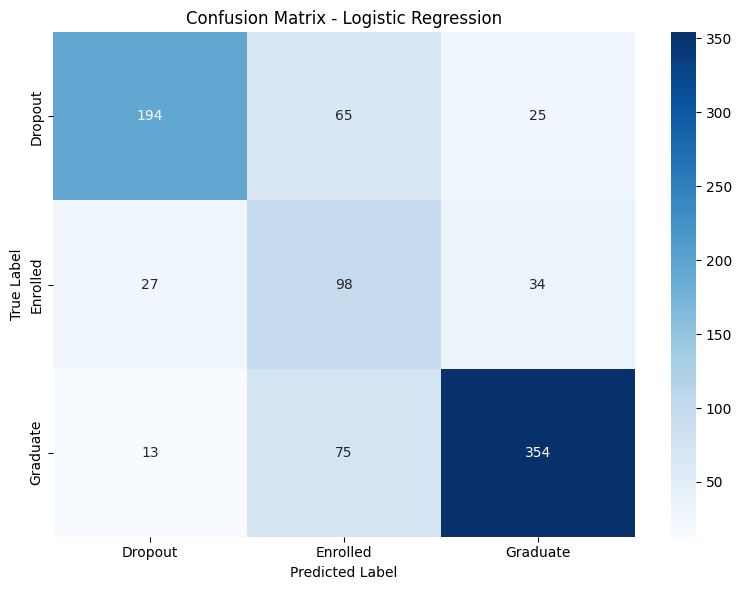


📋 Classification Report:
              precision    recall  f1-score   support

     Dropout       0.83      0.68      0.75       284
    Enrolled       0.41      0.62      0.49       159
    Graduate       0.86      0.80      0.83       442

    accuracy                           0.73       885
   macro avg       0.70      0.70      0.69       885
weighted avg       0.77      0.73      0.74       885


✅ Model saved: logistic_regression.pkl


In [ ]:
# ============================================
# CELL 7: Train Logistic Regression
# ============================================
print("\n" + "="*60)
print("📈 TRAINING LOGISTIC REGRESSION (BASELINE)")
print("="*60)

# Initialize model
lr_model = LogisticRegression(random_state=42, max_iter=1000, multi_class='ovr')

# Train
print("\n⏳ Training Logistic Regression...")
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)

# Calculate metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average='weighted')
lr_recall = recall_score(y_test, y_pred_lr, average='weighted')
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')

print(f"\n✅ Logistic Regression Results:")
print(f"   Accuracy:  {lr_accuracy:.4f}")
print(f"   Precision: {lr_precision:.4f}")
print(f"   Recall:    {lr_recall:.4f}")
print(f"   F1-Score:  {lr_f1:.4f}")

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_lr.png', dpi=300)
plt.show()

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=class_names))

# Save model
joblib.dump(lr_model, 'logistic_regression.pkl')
print("\n✅ Model saved: logistic_regression.pkl")


🌳 TRAINING DECISION TREE

⏳ Training Decision Tree...

✅ Decision Tree Results:
   Accuracy:  0.7107
   Precision: 0.7279
   Recall:    0.7107
   F1-Score:  0.7175


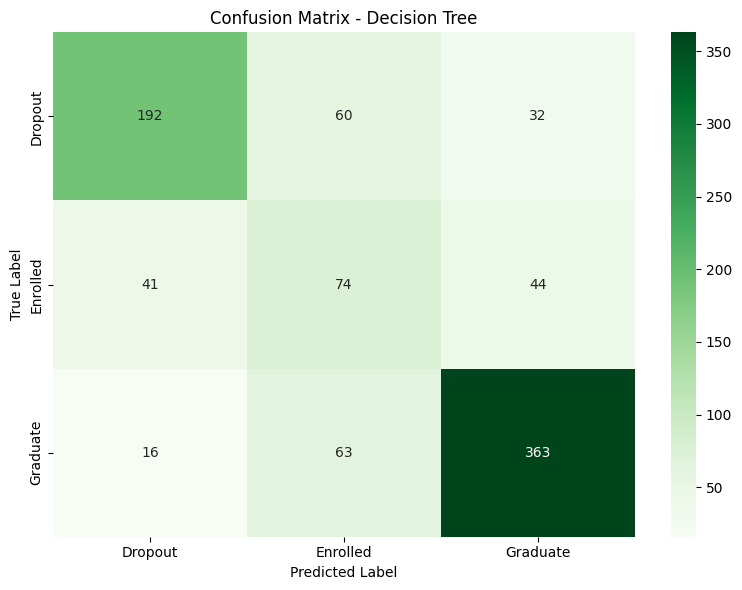


📊 Top 10 Most Important Features (Decision Tree):
                            feature  importance
                         risk_score    0.309532
         academic_performance_score    0.210460
                  failure_rate_sem2    0.097527
Curricular units 1st sem (approved)    0.044308
                             Course    0.030407
                  Age at enrollment    0.029047
                Mother's occupation    0.028605
            Tuition fees up to date    0.026785
                  failure_rate_sem1    0.023981
                  Unemployment rate    0.021975


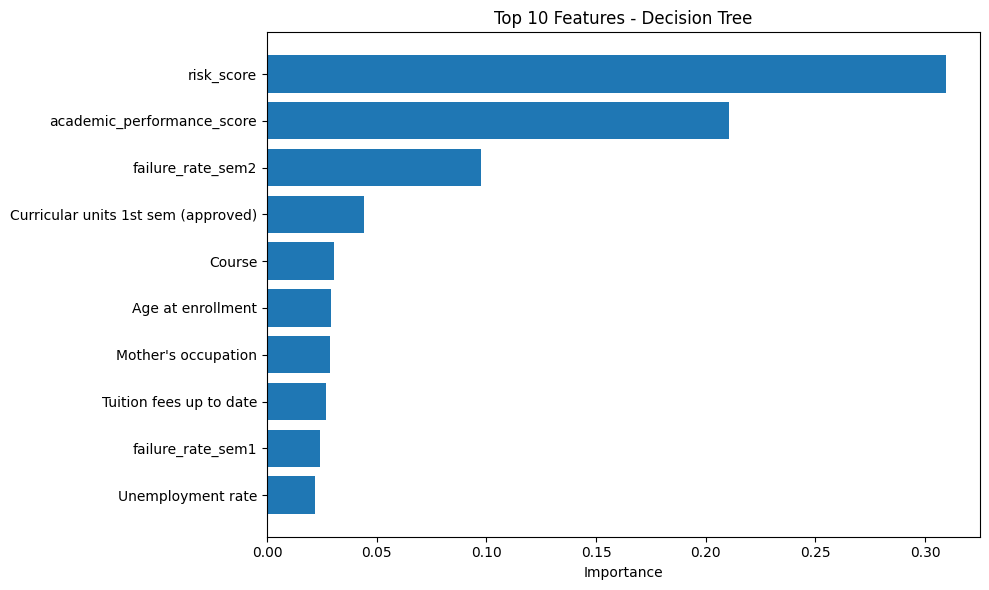


✅ Model saved: decision_tree.pkl


In [ ]:
# ============================================
# CELL 8: Train Decision Tree
# ============================================
print("\n" + "="*60)
print("🌳 TRAINING DECISION TREE")
print("="*60)

# Initialize model with some constraints to prevent overfitting
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,           # Limit tree depth
    min_samples_split=5,    # Minimum samples to split
    min_samples_leaf=2      # Minimum samples in leaf
)

# Train
print("\n⏳ Training Decision Tree...")
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)

# Calculate metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

print(f"\n✅ Decision Tree Results:")
print(f"   Accuracy:  {dt_accuracy:.4f}")
print(f"   Precision: {dt_precision:.4f}")
print(f"   Recall:    {dt_recall:.4f}")
print(f"   F1-Score:  {dt_f1:.4f}")

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_dt.png', dpi=300)
plt.show()

# Feature Importance (for Decision Tree)
feature_importance_dt = pd.DataFrame({
    'feature': feature_names,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Top 10 Most Important Features (Decision Tree):")
print(feature_importance_dt.head(10).to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_dt.head(10)['feature'],
         feature_importance_dt.head(10)['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Features - Decision Tree')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_dt.png', dpi=300)
plt.show()

# Save model
joblib.dump(dt_model, 'decision_tree.pkl')
print("\n✅ Model saved: decision_tree.pkl")


🌲 TRAINING RANDOM FOREST (WITH HYPERPARAMETER TUNING)

⏳ Performing Grid Search with 5-fold CV...
   Testing 81 combinations
Fitting 5 folds for each of 81 candidates, totalling 405 fits

✅ Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
✅ Best CV Score: 0.8366

✅ Random Forest Results on Test Set:
   Accuracy:  0.7571
   Precision: 0.7636
   Recall:    0.7571
   F1-Score:  0.7590


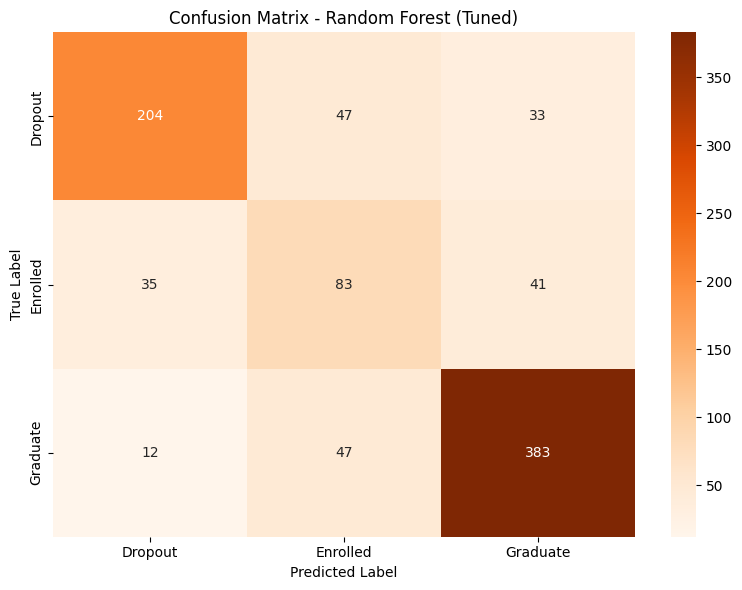


📊 Top 10 Most Important Features (Random Forest):
                            feature  importance
                         risk_score    0.096460
         academic_performance_score    0.083175
                  failure_rate_sem2    0.076879
                  success_rate_sem2    0.071544
Curricular units 2nd sem (approved)    0.058971
   Curricular units 2nd sem (grade)    0.054383
                  success_rate_sem1    0.050639
                  failure_rate_sem1    0.040530
   Curricular units 1st sem (grade)    0.037871
                  Age at enrollment    0.036136


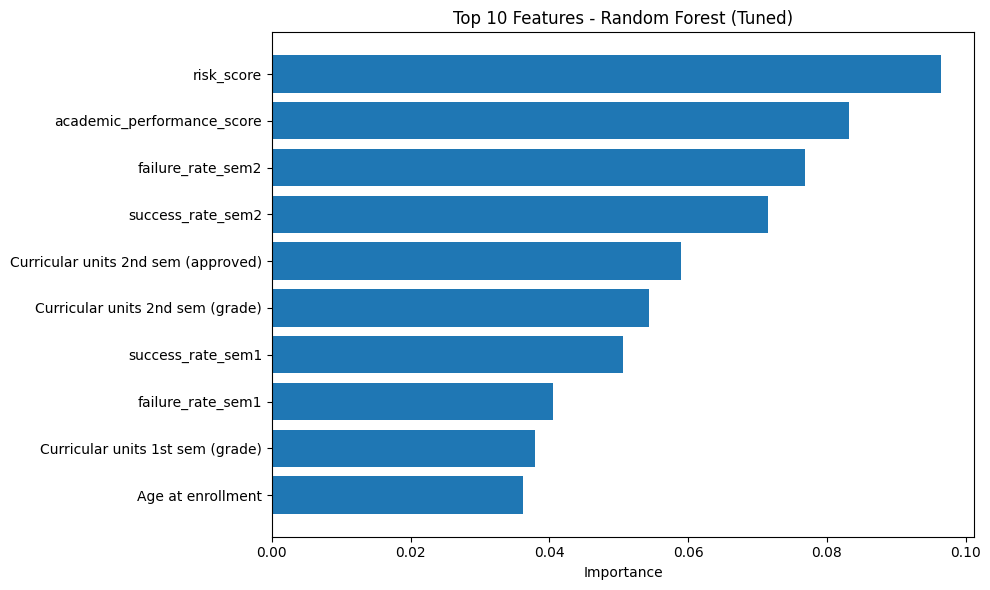


✅ Models saved: random_forest.pkl, grid_search_results.pkl


In [ ]:
# ============================================
# CELL 9: Train Random Forest with Grid Search
# ============================================
print("\n" + "="*60)
print("🌲 TRAINING RANDOM FOREST (WITH HYPERPARAMETER TUNING)")
print("="*60)

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize Random Forest
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grid Search with Cross-Validation
print("\n⏳ Performing Grid Search with 5-fold CV...")
print(f"   Testing {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf'])} combinations")

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Best model
best_rf = grid_search.best_estimator_
print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best CV Score: {grid_search.best_score_:.4f}")

# Predict on test set
y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)

# Calculate metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print(f"\n✅ Random Forest Results on Test Set:")
print(f"   Accuracy:  {rf_accuracy:.4f}")
print(f"   Precision: {rf_precision:.4f}")
print(f"   Recall:    {rf_recall:.4f}")
print(f"   F1-Score:  {rf_f1:.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Random Forest (Tuned)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=300)
plt.show()

# Feature Importance
feature_importance_rf = pd.DataFrame({
    'feature': feature_names,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Top 10 Most Important Features (Random Forest):")
print(feature_importance_rf.head(10).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_rf.head(10)['feature'],
         feature_importance_rf.head(10)['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Features - Random Forest (Tuned)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=300)
plt.show()

# Save models
joblib.dump(best_rf, 'random_forest.pkl')
joblib.dump(grid_search, 'grid_search_results.pkl')
print("\n✅ Models saved: random_forest.pkl, grid_search_results.pkl")


📊 MODEL COMPARISON

                Model  Accuracy  Precision   Recall  F1-Score Training Time
  Logistic Regression  0.729944   0.768114 0.729944  0.742635          Fast
        Decision Tree  0.710734   0.727903 0.710734  0.717452          Fast
Random Forest (Tuned)  0.757062   0.763626 0.757062  0.759035        Medium


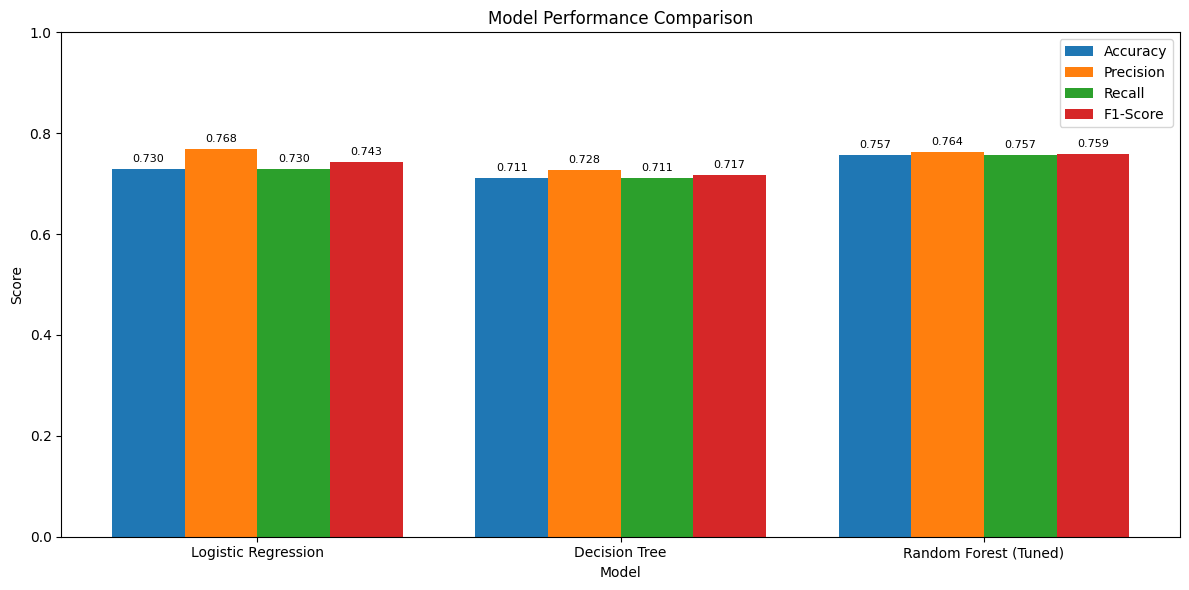


✅ Best Model: Random Forest (Tuned) (F1-Score: 0.7590)
✅ Best model saved as: best_model.pkl


In [ ]:
# ============================================
# CELL 10: Model Comparison
# ============================================
print("\n" + "="*60)
print("📊 MODEL COMPARISON")
print("="*60)

# Create comparison dataframe
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest (Tuned)'],
    'Accuracy': [lr_accuracy, dt_accuracy, rf_accuracy],
    'Precision': [lr_precision, dt_precision, rf_precision],
    'Recall': [lr_recall, dt_recall, rf_recall],
    'F1-Score': [lr_f1, dt_f1, rf_f1],
    'Training Time': ['Fast', 'Fast', 'Medium']
})

print("\n" + "="*60)
print(results.to_string(index=False))
print("="*60)

# Visualize comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results['Model']))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i*width, results[metric], width, label=metric)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results['Model'])
ax.legend()
ax.set_ylim(0, 1)

# Add value labels on bars
for i, metric in enumerate(metrics):
    for j, value in enumerate(results[metric]):
        ax.text(j + i*width, value + 0.01, f'{value:.3f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()

# Determine best model
best_model_name = results.loc[results['F1-Score'].idxmax(), 'Model']
best_f1 = results['F1-Score'].max()
print(f"\n✅ Best Model: {best_model_name} (F1-Score: {best_f1:.4f})")

if best_model_name == 'Random Forest (Tuned)':
    best_model = best_rf
elif best_model_name == 'Decision Tree':
    best_model = dt_model
else:
    best_model = lr_model

# Save best model separately
joblib.dump(best_model, 'best_model.pkl')
print("✅ Best model saved as: best_model.pkl")


🔄 CROSS-VALIDATION

📊 Logistic Regression - 5-Fold Cross-Validation:
   Accuracy:  0.7427 (+/- 0.0469)
   F1-Score:  0.7424 (+/- 0.0485)

📊 Decision Tree - 5-Fold Cross-Validation:
   Accuracy:  0.7535 (+/- 0.0929)
   F1-Score:  0.7530 (+/- 0.0960)

📊 Random Forest - 5-Fold Cross-Validation:
   Accuracy:  0.8370 (+/- 0.1086)
   F1-Score:  0.8366 (+/- 0.1106)


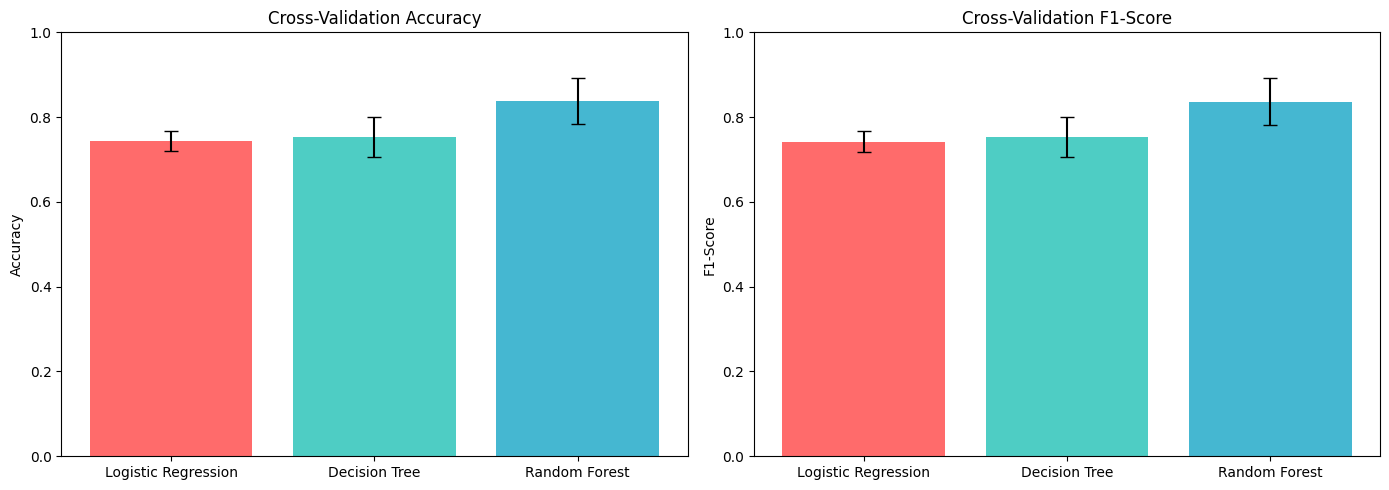

In [ ]:
# ============================================
# CELL 11: Cross-Validation
# ============================================
print("\n" + "="*60)
print("🔄 CROSS-VALIDATION")
print("="*60)

models_to_cv = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': best_rf
}

cv_results = {}

for name, model in models_to_cv.items():
    print(f"\n📊 {name} - 5-Fold Cross-Validation:")

    # Accuracy CV
    cv_scores_acc = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"   Accuracy:  {cv_scores_acc.mean():.4f} (+/- {cv_scores_acc.std()*2:.4f})")

    # F1 CV
    cv_scores_f1 = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_weighted')
    print(f"   F1-Score:  {cv_scores_f1.mean():.4f} (+/- {cv_scores_f1.std()*2:.4f})")

    cv_results[name] = {
        'accuracy_mean': cv_scores_acc.mean(),
        'accuracy_std': cv_scores_acc.std(),
        'f1_mean': cv_scores_f1.mean(),
        'f1_std': cv_scores_f1.std()
    }

# Visualize CV results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
models = list(cv_results.keys())
acc_means = [cv_results[m]['accuracy_mean'] for m in models]
acc_stds = [cv_results[m]['accuracy_std'] for m in models]

axes[0].bar(models, acc_means, yerr=acc_stds, capsize=5, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Cross-Validation Accuracy')
axes[0].set_ylim(0, 1)

# F1
f1_means = [cv_results[m]['f1_mean'] for m in models]
f1_stds = [cv_results[m]['f1_std'] for m in models]

axes[1].bar(models, f1_means, yerr=f1_stds, capsize=5, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Cross-Validation F1-Score')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('cross_validation_results.png', dpi=300)
plt.show()

In [ ]:
# ============================================
# CELL 12: Save All Results
# ============================================
print("\n" + "="*60)
print("💾 SAVING ALL RESULTS")
print("="*60)

# Save results to CSV
results.to_csv('model_training_results.csv', index=False)
print("✅ Saved: model_training_results.csv")

# Save feature importance
feature_importance_rf.to_csv('feature_importance_rf.csv', index=False)
print("✅ Saved: feature_importance_rf.csv")

# Save classification reports
with open('classification_reports.txt', 'w') as f:
    f.write("CLASSIFICATION REPORTS\n")
    f.write("="*60 + "\n\n")

    f.write("LOGISTIC REGRESSION:\n")
    f.write("-"*40 + "\n")
    f.write(classification_report(y_test, y_pred_lr, target_names=class_names))
    f.write("\n\n")

    f.write("DECISION TREE:\n")
    f.write("-"*40 + "\n")
    f.write(classification_report(y_test, y_pred_dt, target_names=class_names))
    f.write("\n\n")

    f.write("RANDOM FOREST:\n")
    f.write("-"*40 + "\n")
    f.write(classification_report(y_test, y_pred_rf, target_names=class_names))

print("✅ Saved: classification_reports.txt")

# Save to Google Drive
save_path = '/content/drive/MyDrive/dropout-project/'

# Models
joblib.dump(lr_model, f'{save_path}models/logistic_regression.pkl')
joblib.dump(dt_model, f'{save_path}models/decision_tree.pkl')
joblib.dump(best_rf, f'{save_path}models/random_forest.pkl')
joblib.dump(best_model, f'{save_path}models/best_model.pkl')

# Results
results.to_csv(f'{save_path}results/model_training_results.csv', index=False)
feature_importance_rf.to_csv(f'{save_path}results/feature_importance_rf.csv', index=False)

print(f"\n✅ All files saved to Google Drive: {save_path}")

# Create summary report
with open('model_training_summary.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("STUDENT DROPOUT PREDICTION - MODEL TRAINING SUMMARY\n")
    f.write("="*60 + "\n\n")

    f.write(f"Dataset: {X_train.shape[0]} training samples, {X_test.shape[0]} test samples\n")
    f.write(f"Features: {X_train.shape[1]}\n")
    f.write(f"Target classes: {class_names}\n\n")

    f.write("MODEL PERFORMANCE:\n")
    f.write("-"*40 + "\n")
    f.write(results.to_string(index=False))
    f.write("\n\n")

    f.write(f"BEST MODEL: {best_model_name}\n")
    f.write(f"Best F1-Score: {best_f1:.4f}\n\n")

    f.write("TOP 10 FEATURES:\n")
    f.write("-"*40 + "\n")
    for i, row in feature_importance_rf.head(10).iterrows():
        f.write(f"{i+1}. {row['feature']}: {row['importance']:.4f}\n")

    f.write("\n" + "="*60 + "\n")
    f.write("MODEL TRAINING COMPLETE! READY FOR API INTEGRATION.\n")
    f.write("="*60)

print("\n✅ Saved: model_training_summary.txt")
print("\n📋 Summary Report:")
!cat model_training_summary.txt


💾 SAVING ALL RESULTS
✅ Saved: model_training_results.csv
✅ Saved: feature_importance_rf.csv
✅ Saved: classification_reports.txt

✅ All files saved to Google Drive: /content/drive/MyDrive/dropout-project/

✅ Saved: model_training_summary.txt

📋 Summary Report:
STUDENT DROPOUT PREDICTION - MODEL TRAINING SUMMARY

Dataset: 5301 training samples, 885 test samples
Features: 24
Target classes: ['Dropout' 'Enrolled' 'Graduate']

MODEL PERFORMANCE:
----------------------------------------
                Model  Accuracy  Precision   Recall  F1-Score Training Time
  Logistic Regression  0.729944   0.768114 0.729944  0.742635          Fast
        Decision Tree  0.710734   0.727903 0.710734  0.717452          Fast
Random Forest (Tuned)  0.757062   0.763626 0.757062  0.759035        Medium

BEST MODEL: Random Forest (Tuned)
Best F1-Score: 0.7590

TOP 10 FEATURES:
----------------------------------------
24. risk_score: 0.0965
23. academic_performance_score: 0.0832
20. failure_rate_sem2: 0.0769
1

In [ ]:
# ============================================
# CELL 13: Create ZIP File with All Results
# ============================================
print("\n" + "="*60)
print("📦 CREATING FINAL ZIP FILE")
print("="*60)

zip_filename = 'model_training_results.zip'

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    # Add model files
    model_files = ['logistic_regression.pkl', 'decision_tree.pkl',
                   'random_forest.pkl', 'best_model.pkl']
    for file in model_files:
        if os.path.exists(file):
            zipf.write(file)
            print(f"✅ Added model: {file}")

    # Add results files
    result_files = ['model_training_results.csv', 'feature_importance_rf.csv',
                    'classification_reports.txt', 'model_training_summary.txt']
    for file in result_files:
        if os.path.exists(file):
            zipf.write(file)
            print(f"✅ Added result: {file}")

    # Add images
    image_files = ['confusion_matrix_lr.png', 'confusion_matrix_dt.png',
                   'confusion_matrix_rf.png', 'model_comparison.png',
                   'feature_importance_rf.png', 'cross_validation_results.png']
    for file in image_files:
        if os.path.exists(file):
            zipf.write(file)
            print(f"✅ Added image: {file}")

print(f"\n📦 ZIP file created: {zip_filename}")
print(f"📊 Size: {os.path.getsize(zip_filename) / 1024 / 1024:.2f} MB")


📦 CREATING FINAL ZIP FILE
✅ Added model: logistic_regression.pkl
✅ Added model: decision_tree.pkl
✅ Added model: random_forest.pkl
✅ Added model: best_model.pkl
✅ Added result: model_training_results.csv
✅ Added result: feature_importance_rf.csv
✅ Added result: classification_reports.txt
✅ Added result: model_training_summary.txt
✅ Added image: confusion_matrix_lr.png
✅ Added image: confusion_matrix_dt.png
✅ Added image: confusion_matrix_rf.png
✅ Added image: model_comparison.png
✅ Added image: feature_importance_rf.png
✅ Added image: cross_validation_results.png

📦 ZIP file created: model_training_results.zip
📊 Size: 14.19 MB


In [ ]:
# ============================================
# CELL 14: Download ZIP File
# ============================================
print("\n" + "="*60)
print("📥 DOWNLOADING RESULTS")
print("="*60)
print("\n⏳ Download starting automatically...")

files.download(zip_filename)

print("\n✅ Download started! Check your browser downloads folder.")


📥 DOWNLOADING RESULTS

⏳ Download starting automatically...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download started! Check your browser downloads folder.
